 <font size="10">**Script 06: Data transformation and dimensionality reduction: part 2**</font>
***

<div class="alert alert-info">
    
<b> <h1> ℹ️ <strong> <font size="6" color="black"> Important notebook information </font> </strong> </h1> </b>
    <hr>
    <font size="4" color="black">
        The purpose of this notebook is to select features to be used as an input into a scvi model for batch correction<br> <br>
    This scipt will transform the data using a function which utalises scanpy preprocessing functions</font>

# Import packages

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import os
import sys
import datetime
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.signal import find_peaks

import warnings
warnings.filterwarnings("ignore")

inline_rc = dict(mpl.rcParams)

#to set unique date for outputs
calc_date = datetime.datetime.now()
date=calc_date.strftime('%Y-%m-%d')
#date=calc_date.strftime('%d-%m-%Y')
date = date.replace('-', '')

sc.settings.verbosity = 2

# Note: package versions can be located in dependencies at the bottom of the script

# User settings interaction block
This notbook is to transform the data ready for futher exploration and provide template to how the data will be transformed in other scripts

In [2]:
### User settings block ###

# Set root directory so all files and outputs can be found within one overarching location
root_directory = '/home/jovyan/mount_farm/nfs/team298/ar32/Whole_embryo/'

# set directory path to Whole_Embryo_utils.py: This python script hold modules / functions which are used within the script 
Whole_Embryo_utils_path = root_directory + "Utlis/"


# set directory path for the combined embryo anndata object from script 05
Comb_path = root_directory + 'Outputs/Objects/Post_QC/Combined_n_3_raw_counts_low_quailty_cells_removed_20220427.h5ad'
data_name = 'Combined_n_3_raw_counts_low_quailty_cells_removed_20220427'


# set directory path to save script outputs:
Objects_out_path = root_directory + 'Outputs/Objects/Post_QC/' # for anndata object
Metadata_out_path = root_directory + 'Outputs/Metadata/06_PP_DM/' # for metadata



#############################################################################################################################


### Running checking directory paths to Whole_Embryo_utils.py and save directory paths ###

sys.path.append(Whole_Embryo_utils_path)
import Whole_Embryo_utils as eu

print('Checking file path for saving anndata objects:', "\n")
eu.save_path(Objects_out_path)
print("")
print('Checking file path for saving metadata:', "\n")
eu.save_path(Metadata_out_path)

Checking file path for saving anndata objects: 

File path provided exists
To save data to this location use the inputed variable at the start of the file path

Checking file path for saving metadata: 

File path provided exists
To save data to this location use the inputed variable at the start of the file path


# Script start

In [3]:
# Load in anndata object
print('\033[1m' + f'Anndata object to load: {data_name}'+ '\033[0m')
adata = eu.load(Comb_path, Method='h5ad')
print('\033[1m' + 'Data loaded under variable: adata'+ '\033[0m')

Anndata object to load: Combined_n_3_raw_counts_low_quailty_cells_removed_20220427
Beginning to load data:
Method chosen for loading is h5ad out of the options: h5ad , h5 or mtx

Data loaded in successfully
Overall shape: (1138964, 36601)
Min count: 0.0
Max count: 16057.0

Data loaded under variable: adata


### Cell cycling genes likely to introduce noise which is not helpful for global view of data - more important for more refined view of data and transitional state cells 
### Removing from global view - mito and ribo kept as more useful in global view 

In [4]:
cc_genes = pd.read_csv('pan_fetal_cc_genes.csv', index_col=0)
cc_genes = list(cc_genes['0'])

# Preprocess up to high var calculation step
- Filter out low quality genes and cell cycle genes
- normalise to 10,000
- natural log 

In [5]:
adata = eu.transform_data(adata, how='frnlh', gene_removal_list = cc_genes ,hvg_min_mean=0.001, hvg_max_mean=10, subset_hvg=False, batch_key_input='haniffa_ID')

filtered out 2017 genes that are detected in less than 5 cells
normalizing by total count per cell
    finished (0:01:16): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
extracting highly variable genes
    finished (0:03:07)


Data transformation complete. 
Runtime: 517.8796761035919s

Options performed in order: ['Filtered low quality genes', 'Removed genes from list provided by user', 'Normalised per cell to 10000', 'Natural Logged', 'Gene feature selection by batch']


## Save log norm version of the data with cell cycle genes removed

In [6]:
adata.write('n_3_filter_lowgene_and_cell_cycle_genes_preprocessed_norm_log_highvar_non_subsetted_hvgs_{d}.h5ad'.format(d=date))

In [5]:
adata = sc.read('n_3_filter_lowgene_and_cell_cycle_genes_preprocessed_norm_log_highvar_non_subsetted_hvgs_20220513.h5ad')

## Look at HVG output and gene norm dispersions

In [7]:
# number of high var genes
adata.var['highly_variable'].value_counts()

False    30452
True      3590
Name: highly_variable, dtype: int64

In [8]:
adata.var['highly_variable_nbatches'].value_counts()

0    28810
3     2283
1     1815
2     1134
Name: highly_variable_nbatches, dtype: int64

In [9]:
adata.var['highly_variable_intersection'].value_counts()

False    31759
True      2283
Name: highly_variable_intersection, dtype: int64

In [10]:
adata.var.groupby(['highly_variable','highly_variable_intersection','highly_variable_nbatches']).apply(len)

highly_variable  highly_variable_intersection  highly_variable_nbatches
False            False                         0                           28786
                                               1                            1466
                                               2                             200
True             False                         0                              24
                                               1                             349
                                               2                             934
                 True                          3                            2283
dtype: int64

In [11]:
dispersion_norm = adata.var['dispersions_norm'].values.astype('float32')
dispersion_norm = dispersion_norm[~np.isnan(dispersion_norm)]
dispersion_norm[::-1].sort()
n_top_genes = [1000, 2000, 3000, 5000, 7500, 8000, 10000, 12000, 15000]
for n in n_top_genes:
    disp_cut_off = dispersion_norm[n - 1]
    gene_subset = adata.var['dispersions_norm'].values >= disp_cut_off
    name = 'adata_subset_' + str(n)
    name2 = 'disp_cut_off_' + str(n)
    globals()[name] = adata[:,gene_subset]
    globals()[name2] = disp_cut_off
    print(name)
    print(name2)
    print("")

adata_subset_1000
disp_cut_off_1000

adata_subset_2000
disp_cut_off_2000

adata_subset_3000
disp_cut_off_3000

adata_subset_5000
disp_cut_off_5000

adata_subset_7500
disp_cut_off_7500

adata_subset_8000
disp_cut_off_8000

adata_subset_10000
disp_cut_off_10000

adata_subset_12000
disp_cut_off_12000

adata_subset_15000
disp_cut_off_15000



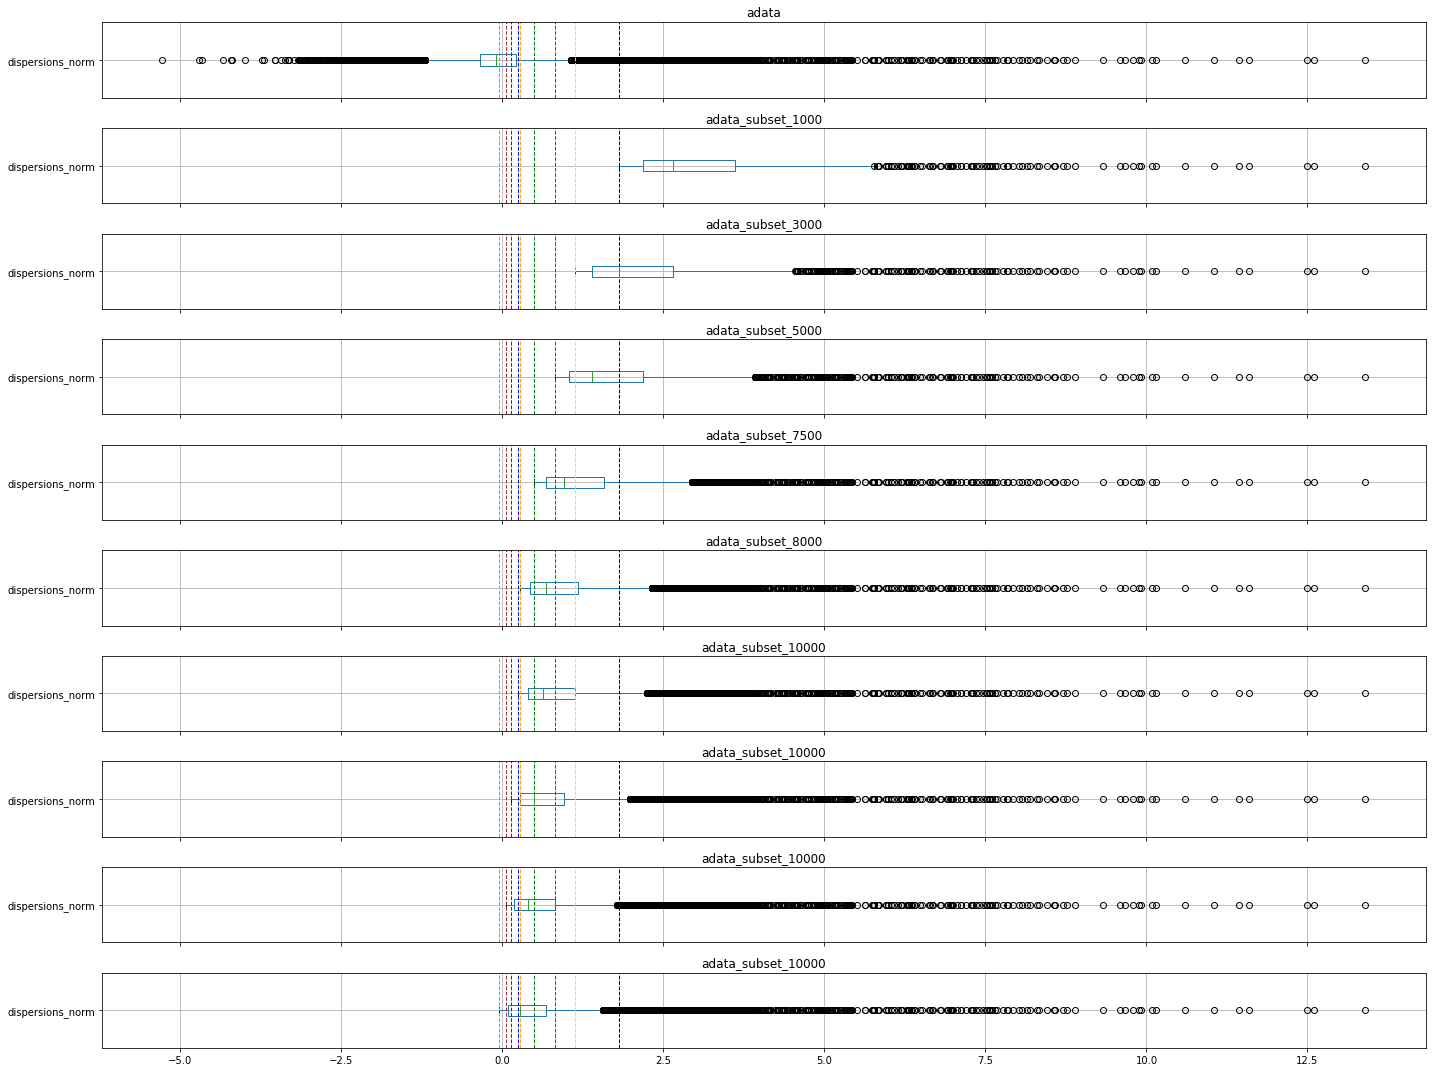

In [12]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10) = plt.subplots(figsize=(20, 15), nrows=10, sharex=True)

adata.var.boxplot(column='dispersions_norm', vert=False, ax=ax1)
ax1.set_title('adata')
ax1.axvline(x=disp_cut_off_1000,c="black",linewidth=1,linestyle = '--')
ax1.axvline(x=disp_cut_off_2000,c="pink",linewidth=1,linestyle = '--')
ax1.axvline(x=disp_cut_off_3000,c="red",linewidth=1,linestyle = '--')
ax1.axvline(x=disp_cut_off_5000,c="green",linewidth=1,linestyle = '--')
ax1.axvline(x=disp_cut_off_7500,c="orange",linewidth=1,linestyle = '--')
ax1.axvline(x=disp_cut_off_8000,c="blue",linewidth=1,linestyle = '--')
ax1.axvline(x=disp_cut_off_10000,c="purple",linewidth=1,linestyle = '--')
ax1.axvline(x=disp_cut_off_12000,c="brown",linewidth=1,linestyle = '--')
ax1.axvline(x=disp_cut_off_15000,c="lime",linewidth=1,linestyle = '--')

adata_subset_1000.var.boxplot(column='dispersions_norm', vert=False, ax=ax2)
ax2.set_title('adata_subset_1000')
ax2.axvline(x=disp_cut_off_1000,c="black",linewidth=1,linestyle = '--')
ax2.axvline(x=disp_cut_off_2000,c="pink",linewidth=1,linestyle = '--')
ax2.axvline(x=disp_cut_off_3000,c="red",linewidth=1,linestyle = '--')
ax2.axvline(x=disp_cut_off_5000,c="green",linewidth=1,linestyle = '--')
ax2.axvline(x=disp_cut_off_7500,c="orange",linewidth=1,linestyle = '--')
ax2.axvline(x=disp_cut_off_8000,c="blue",linewidth=1,linestyle = '--')
ax2.axvline(x=disp_cut_off_10000,c="purple",linewidth=1,linestyle = '--')
ax2.axvline(x=disp_cut_off_12000,c="brown",linewidth=1,linestyle = '--')
ax2.axvline(x=disp_cut_off_15000,c="lime",linewidth=1,linestyle = '--')


adata_subset_2000.var.boxplot(column='dispersions_norm', vert=False, ax=ax3)
ax3.set_title('adata_subset_3000')
ax3.axvline(x=disp_cut_off_1000,c="black",linewidth=1,linestyle = '--')
ax3.axvline(x=disp_cut_off_2000,c="pink",linewidth=1,linestyle = '--')
ax3.axvline(x=disp_cut_off_3000,c="red",linewidth=1,linestyle = '--')
ax3.axvline(x=disp_cut_off_5000,c="green",linewidth=1,linestyle = '--')
ax3.axvline(x=disp_cut_off_7500,c="orange",linewidth=1,linestyle = '--')
ax3.axvline(x=disp_cut_off_8000,c="blue",linewidth=1,linestyle = '--')
ax3.axvline(x=disp_cut_off_10000,c="purple",linewidth=1,linestyle = '--')
ax3.axvline(x=disp_cut_off_12000,c="brown",linewidth=1,linestyle = '--')
ax3.axvline(x=disp_cut_off_15000,c="lime",linewidth=1,linestyle = '--')

adata_subset_3000.var.boxplot(column='dispersions_norm', vert=False, ax=ax4)
ax4.set_title('adata_subset_5000')
ax4.axvline(x=disp_cut_off_1000,c="black",linewidth=1,linestyle = '--')
ax4.axvline(x=disp_cut_off_2000,c="pink",linewidth=1,linestyle = '--')
ax4.axvline(x=disp_cut_off_3000,c="red",linewidth=1,linestyle = '--')
ax4.axvline(x=disp_cut_off_5000,c="green",linewidth=1,linestyle = '--')
ax4.axvline(x=disp_cut_off_7500,c="orange",linewidth=1,linestyle = '--')
ax4.axvline(x=disp_cut_off_8000,c="blue",linewidth=1,linestyle = '--')
ax4.axvline(x=disp_cut_off_10000,c="purple",linewidth=1,linestyle = '--')
ax4.axvline(x=disp_cut_off_12000,c="brown",linewidth=1,linestyle = '--')
ax4.axvline(x=disp_cut_off_15000,c="lime",linewidth=1,linestyle = '--')


adata_subset_5000.var.boxplot(column='dispersions_norm', vert=False, ax=ax5)
ax5.set_title('adata_subset_7500')
ax5.axvline(x=disp_cut_off_1000,c="black",linewidth=1,linestyle = '--')
ax5.axvline(x=disp_cut_off_2000,c="pink",linewidth=1,linestyle = '--')
ax5.axvline(x=disp_cut_off_3000,c="red",linewidth=1,linestyle = '--')
ax5.axvline(x=disp_cut_off_5000,c="green",linewidth=1,linestyle = '--')
ax5.axvline(x=disp_cut_off_7500,c="orange",linewidth=1,linestyle = '--')
ax5.axvline(x=disp_cut_off_8000,c="blue",linewidth=1,linestyle = '--')
ax5.axvline(x=disp_cut_off_10000,c="purple",linewidth=1,linestyle = '--')
ax5.axvline(x=disp_cut_off_12000,c="brown",linewidth=1,linestyle = '--')
ax5.axvline(x=disp_cut_off_15000,c="lime",linewidth=1,linestyle = '--')


adata_subset_7500.var.boxplot(column='dispersions_norm', vert=False, ax=ax6)
ax6.set_title('adata_subset_8000')
ax6.axvline(x=disp_cut_off_1000,c="black",linewidth=1,linestyle = '--')
ax6.axvline(x=disp_cut_off_2000,c="pink",linewidth=1,linestyle = '--')
ax6.axvline(x=disp_cut_off_3000,c="red",linewidth=1,linestyle = '--')
ax6.axvline(x=disp_cut_off_5000,c="green",linewidth=1,linestyle = '--')
ax6.axvline(x=disp_cut_off_7500,c="orange",linewidth=1,linestyle = '--')
ax6.axvline(x=disp_cut_off_8000,c="blue",linewidth=1,linestyle = '--')
ax6.axvline(x=disp_cut_off_10000,c="purple",linewidth=1,linestyle = '--')
ax6.axvline(x=disp_cut_off_12000,c="brown",linewidth=1,linestyle = '--')
ax6.axvline(x=disp_cut_off_15000,c="lime",linewidth=1,linestyle = '--')


adata_subset_8000.var.boxplot(column='dispersions_norm', vert=False, ax=ax7)
ax7.set_title('adata_subset_10000')
ax7.axvline(x=disp_cut_off_1000,c="black",linewidth=1,linestyle = '--')
ax7.axvline(x=disp_cut_off_2000,c="pink",linewidth=1,linestyle = '--')
ax7.axvline(x=disp_cut_off_3000,c="red",linewidth=1,linestyle = '--')
ax7.axvline(x=disp_cut_off_5000,c="green",linewidth=1,linestyle = '--')
ax7.axvline(x=disp_cut_off_7500,c="orange",linewidth=1,linestyle = '--')
ax7.axvline(x=disp_cut_off_8000,c="blue",linewidth=1,linestyle = '--')
ax7.axvline(x=disp_cut_off_10000,c="purple",linewidth=1,linestyle = '--')
ax7.axvline(x=disp_cut_off_12000,c="brown",linewidth=1,linestyle = '--')
ax7.axvline(x=disp_cut_off_15000,c="lime",linewidth=1,linestyle = '--')

adata_subset_10000.var.boxplot(column='dispersions_norm', vert=False, ax=ax8)
ax8.set_title('adata_subset_10000')
ax8.axvline(x=disp_cut_off_1000,c="black",linewidth=1,linestyle = '--')
ax8.axvline(x=disp_cut_off_2000,c="pink",linewidth=1,linestyle = '--')
ax8.axvline(x=disp_cut_off_3000,c="red",linewidth=1,linestyle = '--')
ax8.axvline(x=disp_cut_off_5000,c="green",linewidth=1,linestyle = '--')
ax8.axvline(x=disp_cut_off_7500,c="orange",linewidth=1,linestyle = '--')
ax8.axvline(x=disp_cut_off_8000,c="blue",linewidth=1,linestyle = '--')
ax8.axvline(x=disp_cut_off_10000,c="purple",linewidth=1,linestyle = '--')
ax8.axvline(x=disp_cut_off_12000,c="brown",linewidth=1,linestyle = '--')
ax8.axvline(x=disp_cut_off_15000,c="lime",linewidth=1,linestyle = '--')

adata_subset_12000.var.boxplot(column='dispersions_norm', vert=False, ax=ax9)
ax9.set_title('adata_subset_10000')
ax9.axvline(x=disp_cut_off_1000,c="black",linewidth=1,linestyle = '--')
ax9.axvline(x=disp_cut_off_2000,c="pink",linewidth=1,linestyle = '--')
ax9.axvline(x=disp_cut_off_3000,c="red",linewidth=1,linestyle = '--')
ax9.axvline(x=disp_cut_off_5000,c="green",linewidth=1,linestyle = '--')
ax9.axvline(x=disp_cut_off_7500,c="orange",linewidth=1,linestyle = '--')
ax9.axvline(x=disp_cut_off_8000,c="blue",linewidth=1,linestyle = '--')
ax9.axvline(x=disp_cut_off_10000,c="purple",linewidth=1,linestyle = '--')
ax9.axvline(x=disp_cut_off_12000,c="brown",linewidth=1,linestyle = '--')
ax9.axvline(x=disp_cut_off_15000,c="lime",linewidth=1,linestyle = '--')

adata_subset_15000.var.boxplot(column='dispersions_norm', vert=False, ax=ax10)
ax10.set_title('adata_subset_10000')
ax10.axvline(x=disp_cut_off_1000,c="black",linewidth=1,linestyle = '--')
ax10.axvline(x=disp_cut_off_2000,c="pink",linewidth=1,linestyle = '--')
ax10.axvline(x=disp_cut_off_3000,c="red",linewidth=1,linestyle = '--')
ax10.axvline(x=disp_cut_off_5000,c="green",linewidth=1,linestyle = '--')
ax10.axvline(x=disp_cut_off_7500,c="orange",linewidth=1,linestyle = '--')
ax10.axvline(x=disp_cut_off_8000,c="blue",linewidth=1,linestyle = '--')
ax10.axvline(x=disp_cut_off_10000,c="purple",linewidth=1,linestyle = '--')
ax10.axvline(x=disp_cut_off_12000,c="brown",linewidth=1,linestyle = '--')
ax10.axvline(x=disp_cut_off_15000,c="lime",linewidth=1,linestyle = '--')

fig.tight_layout()

count    34042.000000
mean         0.000029
std          0.861097
min         -5.284566
25%         -0.351913
50%         -0.104001
75%          0.212696
max         13.400143
Name: dispersions_norm, dtype: float64

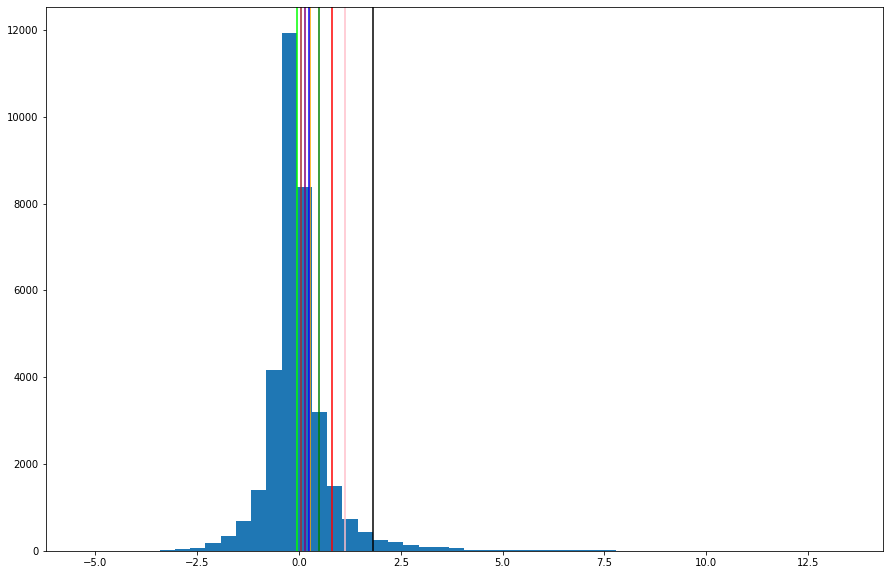

In [13]:
display(adata.var['dispersions_norm'].describe())
plt.figure(figsize=(15, 10))
plt.hist(adata.var['dispersions_norm'], bins=50)
plt.axvline(x=disp_cut_off_1000,c="black")
plt.axvline(x=disp_cut_off_2000,c="pink")
plt.axvline(x=disp_cut_off_3000,c="red")
plt.axvline(x=disp_cut_off_5000,c="green")
plt.axvline(x=disp_cut_off_7500,c="orange")
plt.axvline(x=disp_cut_off_8000,c="blue")
plt.axvline(x=disp_cut_off_10000,c="purple")
plt.axvline(x=disp_cut_off_12000,c="brown")
plt.axvline(x=disp_cut_off_15000,c="lime")

In [14]:
print("-" * 100)
display(adata.var.groupby(['highly_variable','highly_variable_intersection','highly_variable_nbatches']).apply(len))
print("-" * 100)
display(adata_subset_1000.var.groupby(['highly_variable','highly_variable_intersection','highly_variable_nbatches']).apply(len))
print("-" * 100)
display(adata_subset_2000.var.groupby(['highly_variable','highly_variable_intersection','highly_variable_nbatches']).apply(len))
print("-" * 100)
display(adata_subset_3000.var.groupby(['highly_variable','highly_variable_intersection','highly_variable_nbatches']).apply(len))
print("-" * 100)
display(adata_subset_5000.var.groupby(['highly_variable','highly_variable_intersection','highly_variable_nbatches']).apply(len))
print("-" * 100)
display(adata_subset_7500.var.groupby(['highly_variable','highly_variable_intersection','highly_variable_nbatches']).apply(len))
print("-" * 100)
display(adata_subset_8000.var.groupby(['highly_variable','highly_variable_intersection','highly_variable_nbatches']).apply(len))
print("-" * 100)
display(adata_subset_10000.var.groupby(['highly_variable','highly_variable_intersection','highly_variable_nbatches']).apply(len))
print("-" * 100)
display(adata_subset_12000.var.groupby(['highly_variable','highly_variable_intersection','highly_variable_nbatches']).apply(len))
print("-" * 100)
display(adata_subset_15000.var.groupby(['highly_variable','highly_variable_intersection','highly_variable_nbatches']).apply(len))
print("-" * 100)

----------------------------------------------------------------------------------------------------


highly_variable  highly_variable_intersection  highly_variable_nbatches
False            False                         0                           28786
                                               1                            1466
                                               2                             200
True             False                         0                              24
                                               1                             349
                                               2                             934
                 True                          3                            2283
dtype: int64

----------------------------------------------------------------------------------------------------


highly_variable  highly_variable_intersection  highly_variable_nbatches
False            False                         0                            56
                                               1                            30
                                               2                             2
True             False                         1                            22
                                               2                            24
                 True                          3                           866
dtype: int64

----------------------------------------------------------------------------------------------------


...

----------------------------------------------------------------------------------------------------


highly_variable  highly_variable_intersection  highly_variable_nbatches
False            False                         0                           6803
                                               1                           1407
                                               2                            200
True             False                         0                             24
                                               1                            349
                                               2                            934
                 True                          3                           2283
dtype: int64

----------------------------------------------------------------------------------------------------


highly_variable  highly_variable_intersection  highly_variable_nbatches
False            False                         0                           9762
                                               1                           1448
                                               2                            200
True             False                         0                             24
                                               1                            349
                                               2                            934
                 True                          3                           2283
dtype: int64

----------------------------------------------------------------------------------------------------


# Load in raw data, add as layer to each object and cut to relevant genes ready for SCVI model integration
- From distributions above it is not worth testing all cutoffs
- Similar dataset looking at cross organ analysis used the top 7500 genes for integration
- Saving feature selection most relevant

In [15]:
adata_raw = sc.read(Comb_path)

In [16]:
adatas = [adata_subset_5000, adata_subset_7500, adata_subset_8000, adata_subset_10000] 
names = ['adata_subset_5000', 'adata_subset_7500', 'adata_subset_8000', 'adata_subset_10000']

counter = 0
for data in adatas:
    raw_subset = adata_raw[:, adata_raw.var_names.isin(data.var_names)]
    data.layers['raw_counts'] = raw_subset.X.copy()
    name = names[counter]
    data.write('./high_var_by_dispersion_anndata_objects_for_scvi/n_3_log_norm_{n}_top_gene_dispersion_norm_for_SCVI_input_{d}.h5ad'.format(n=name, d=date))
    counter +=1

### Output
- with increase in cell numbers to find rarer celltypes it will require higher number of features to distinguish
- not including 1000  or 2000 as normal hvg selection is around 2600 min
- not including 3000 as doesn't capture all original hvgs which should have the most important genes for separating cell states within the data 
- pan-fetal used between 7500 - 8000 and that should be proprotionally 3/4 of the celltypes expect in WE data 
- not going above 10,000 unless 10,000 bad due to computational resourvce availability

### Decision
- For input into scVI use 10,000 for balancve between computational resouce, containing all HVGs inmportant per donor 
- Additionally, see notebook X for per section feature selection showing overlap between the features for total data batch corection and inter sectional varience

***
### Dependencies
Here are some information about resources and import package versions used within this script

In [17]:
%load_ext watermark
%watermark -v -m -p numpy,pandas,scanpy,anndata
#%watermark -u -n -t -z

Python implementation: CPython
Python version       : 3.9.4
IPython version      : 7.24.1

numpy  : 1.20.3
pandas : 1.2.4
scanpy : 1.7.2
anndata: 0.7.6

Compiler    : GCC 9.3.0
OS          : Linux
Release     : 4.15.0-197-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 60
Architecture: 64bit

